# Used car price prediction

Predicting the selling price of a used car from its specs, using the CarDekho used car dataset from Kaggle.

The plan is to clean the data up, do some feature engineering, start with a basic linear regression as a baseline, and then work up to something better and fine tune it.

## 1. Getting the data

Pulling the dataset down with kagglehub. It ships with a few different csvs, I'm using `car-details-v4.csv` since it has the most features to work with (engine, power, torque, dimensions), rather than just the make/model/year.

I saved the csvs into `data/` so the rest of the notebook just reads from there.

In [1]:
import kagglehub 

path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Path to dataset files: /Users/zainbabar/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("data/car-details-v4.csv")

## 2. First look at the data

2059 rows and 20 columns. checking what the columns actually look like and how much of it is missing.

In [4]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [5]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

engine, power, torque, drivetrain and the dimension columns all have nulls. it's a small enough chunk of the data that dropping those rows is fine (2059 -> 1874), and I'm keeping a copy of the raw frame around just in case.

In [7]:
raw_data = data
data = data.dropna()

In [8]:
data.info()

<class 'pandas.DataFrame'>
Index: 1874 entries, 0 to 2057
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   str    
 1   Model               1874 non-null   str    
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   str    
 6   Transmission        1874 non-null   str    
 7   Location            1874 non-null   str    
 8   Color               1874 non-null   str    
 9   Owner               1874 non-null   str    
 10  Seller Type         1874 non-null   str    
 11  Engine              1874 non-null   str    
 12  Max Power           1874 non-null   str    
 13  Max Torque          1874 non-null   str    
 14  Drivetrain          1874 non-null   str    
 15  Length              1874 non-null   float64
 16  Width               18

In [9]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


quick look at the distributions of the numeric columns.

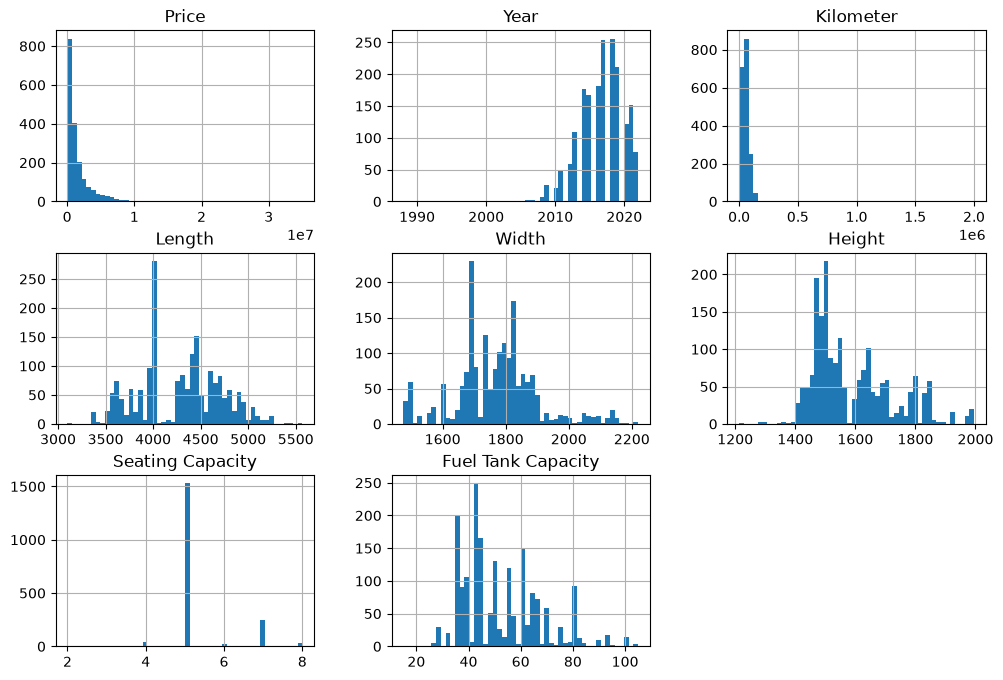

In [10]:
data.hist(bins=50, figsize=(12,8))
plt.show()

## 3. Train/test split

split into train/test set, skip stratification for now

In [11]:
features = data.drop(columns=["Price"])
prices = data["Price"]

from sklearn.model_selection import train_test_split

In [12]:
features_train, features_test, prices_train, prices_test = train_test_split(features, prices, test_size=0.2, random_state=42)
train_set = pd.concat([features_train, prices_train], axis=1)

## 4. Look for correlations

In [13]:
corr_matrix = train_set.corr(numeric_only=True)

In [14]:
corr_matrix["Price"]

Year                  0.318989
Kilometer            -0.143158
Length                0.611532
Width                 0.596076
Height                0.107755
Seating Capacity      0.020716
Fuel Tank Capacity    0.599215
Price                 1.000000
Name: Price, dtype: float64

looks like the strongest numeric indicator is the length/width/fuel tank, implying that larger cars are more expensive. then year.

but, intuitively we know that the biggest driving factor would probably be the make/model, i.e. luxury cars cost more

## 5. Feature engineering

starting with the make, since that's the one I expect to matter most. there's a long tail of makes that barely show up though, so anything with fewer than 10 rows gets bucketed into "Other".

In [15]:
counts = train_set["Make"].value_counts()
rare = counts[counts < 10].index # makes that don't appear very often, not very useful for use
train_set["Make"] = train_set["Make"].replace(rare, "Other") # combine all rare makes into an "other" category

In [16]:
train_set = pd.get_dummies(train_set, columns=["Make"], drop_first=True)
train_set.head()

,Model,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,...,Make_Maruti Suzuki,Make_Mercedes-Benz,Make_Nissan,Make_Other,Make_Renault,Make_Skoda,Make_Tata,Make_Toyota,Make_Volkswagen,Make_Volvo
264,Wagon R LXi Minor,2009,39586,Petrol,Manual,Ranchi,Red,First,Individual,1061 cc,...,True,False,False,False,False,False,False,False,False,False
1326,Alto 800 Lx CNG,2017,45000,CNG,Manual,Pune,Silver,First,Individual,796 cc,...,True,False,False,False,False,False,False,False,False,False
1042,Cooper D 3 Door,2018,17000,Diesel,Automatic,Delhi,Green,First,Individual,1496 cc,...,False,False,False,True,False,False,False,False,False,False
794,GLE 300d 4MATIC LWB,2020,18000,Diesel,Automatic,Delhi,Bronze,First,Individual,1950 cc,...,False,True,False,False,False,False,False,False,False,False
1997,City 1.5 E MT,2013,86000,Petrol,Manual,Mumbai,Purple,Second,Individual,1497 cc,...,False,False,False,False,False,False,False,False,False,False


now the make is one hot encoded.

what else can we do with the data? thinking about it intuitively, some things that probably don't affect the price would be seller type, colour, location. engine size could be useful, but we need to convert it to a numeric value, and owner could also be useful. transmission and fuel type are debatable.

some more data cleaning, auto cars would prob cost more than the manuals so one hot that, and drop colour. ordinal encode owners, with unreg being 4, since an unregistered car would prob cost less.

In [17]:
train_set = pd.get_dummies(train_set, columns=["Transmission"], drop_first=True) 
train_set = train_set.drop(columns=["Color"])

In [18]:
train_set["Owner"].value_counts()

Owner
First               1204
Second               255
Third                 24
UnRegistered Car      16
Name: count, dtype: int64

In [19]:
owner_map = {"First": 1, "Second": 2, "Third": 3, "UnRegistered Car": 4}
train_set["Owner"] = train_set["Owner"].map(owner_map)

In [20]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Fuel Type            1499 non-null   str    
 4   Location             1499 non-null   str    
 5   Owner                1499 non-null   int64  
 6   Seller Type          1499 non-null   str    
 7   Engine               1499 non-null   str    
 8   Max Power            1499 non-null   str    
 9   Max Torque           1499 non-null   str    
 10  Drivetrain           1499 non-null   str    
 11  Length               1499 non-null   float64
 12  Width                1499 non-null   float64
 13  Height               1499 non-null   float64
 14  Seating Capacity     1499 non-null   float64
 15  Fuel Tank Capacity   1499 non-null   float64
 16  Pr

In [21]:
train_set = train_set.drop(columns=["Fuel Type", "Location"])

In [22]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Owner                1499 non-null   int64  
 4   Seller Type          1499 non-null   str    
 5   Engine               1499 non-null   str    
 6   Max Power            1499 non-null   str    
 7   Max Torque           1499 non-null   str    
 8   Drivetrain           1499 non-null   str    
 9   Length               1499 non-null   float64
 10  Width                1499 non-null   float64
 11  Height               1499 non-null   float64
 12  Seating Capacity     1499 non-null   float64
 13  Fuel Tank Capacity   1499 non-null   float64
 14  Price                1499 non-null   int64  
 15  Make_BMW             1499 non-null   bool   
 16  Ma

looking good so far, let's also parse the engine size column to something our model can understand, dropping the cc and converting to an int value

In [23]:
train_set["Engine"] = train_set["Engine"].str.replace(" cc", "", regex=False).astype(int)

In [24]:
train_set["Engine"].info()

<class 'pandas.Series'>
Index: 1499 entries, 264 to 1240
Series name: Engine
Non-Null Count  Dtype
--------------  -----
1499 non-null   int64
dtypes: int64(1)
memory usage: 23.4 KB


now we have to turn the power and torque into integer values too, which will be a little more tricky

In [25]:
train_set["Max Power"] = train_set["Max Power"].str.extract(r"(\d+\.?\d*)").astype(float)
train_set["Max Torque"] = train_set["Max Torque"].str.extract(r"(\d+\.?\d*)").astype(float)

In [26]:
train_set[["Max Power", "Max Torque"]].info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Max Power   1499 non-null   float64
 1   Max Torque  1499 non-null   float64
dtypes: float64(2)
memory usage: 35.1 KB


In [27]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Owner                1499 non-null   int64  
 4   Seller Type          1499 non-null   str    
 5   Engine               1499 non-null   int64  
 6   Max Power            1499 non-null   float64
 7   Max Torque           1499 non-null   float64
 8   Drivetrain           1499 non-null   str    
 9   Length               1499 non-null   float64
 10  Width                1499 non-null   float64
 11  Height               1499 non-null   float64
 12  Seating Capacity     1499 non-null   float64
 13  Fuel Tank Capacity   1499 non-null   float64
 14  Price                1499 non-null   int64  
 15  Make_BMW             1499 non-null   bool   
 16  Ma

so now we only have 3 problematic features: model, seller type, and drivetrain

In [28]:
train_set["Drivetrain"].value_counts()

Drivetrain
FWD    1058
RWD     230
AWD     211
Name: count, dtype: int64

only 3 types, and fwd/rwd/awd have no implied order so one hot seems like the right decision here

In [29]:
train_set = pd.get_dummies(train_set, columns=["Drivetrain"], drop_first=True) 

In [30]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Owner                1499 non-null   int64  
 4   Seller Type          1499 non-null   str    
 5   Engine               1499 non-null   int64  
 6   Max Power            1499 non-null   float64
 7   Max Torque           1499 non-null   float64
 8   Length               1499 non-null   float64
 9   Width                1499 non-null   float64
 10  Height               1499 non-null   float64
 11  Seating Capacity     1499 non-null   float64
 12  Fuel Tank Capacity   1499 non-null   float64
 13  Price                1499 non-null   int64  
 14  Make_BMW             1499 non-null   bool   
 15  Make_Ford            1499 non-null   bool   
 16  Ma

In [31]:
train_set["Seller Type"].value_counts()

Seller Type
Individual                 1452
Corporate                    44
Commercial Registration       3
Name: count, dtype: int64

3 non ordinal types, looks fine for one hot encoding

In [32]:
train_set = pd.get_dummies(train_set, columns=["Seller Type"], drop_first=True) 

In [33]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Model                   1499 non-null   str    
 1   Year                    1499 non-null   int64  
 2   Kilometer               1499 non-null   int64  
 3   Owner                   1499 non-null   int64  
 4   Engine                  1499 non-null   int64  
 5   Max Power               1499 non-null   float64
 6   Max Torque              1499 non-null   float64
 7   Length                  1499 non-null   float64
 8   Width                   1499 non-null   float64
 9   Height                  1499 non-null   float64
 10  Seating Capacity        1499 non-null   float64
 11  Fuel Tank Capacity      1499 non-null   float64
 12  Price                   1499 non-null   int64  
 13  Make_BMW                1499 non-null   bool   
 14  Make_Ford               1499 non-null   bool   
 15  M

ok now it looks like the only feature our model won't be able to understand is Model.

In [34]:
train_set["Model"].value_counts()

Model
Swift DZire VDI                      12
City V                               11
X1 sDrive20d xLine                   10
Fortuner 2.8 4x2 AT [2016-2020]      10
Swift DZire VXI                      10
                                     ..
Terrano XV D THP 110 PS               1
Q2 Premium Plus I 40 TFSI quattro     1
Vellfire Hybrid                       1
Kushaq Style 1.0L TSI MT              1
S-Cross Zeta 1.6                      1
Name: count, Length: 829, dtype: int64

tbh there are so many different models of cars that there's no way for us to really encode this in a way a simple model could understand. a more advanced approach could use a neural network to understand the different models, but for now let's just get rid of this feature.

In [35]:
train_set.drop(columns=["Model"], inplace=True)

In [36]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    1499 non-null   int64  
 1   Kilometer               1499 non-null   int64  
 2   Owner                   1499 non-null   int64  
 3   Engine                  1499 non-null   int64  
 4   Max Power               1499 non-null   float64
 5   Max Torque              1499 non-null   float64
 6   Length                  1499 non-null   float64
 7   Width                   1499 non-null   float64
 8   Height                  1499 non-null   float64
 9   Seating Capacity        1499 non-null   float64
 10  Fuel Tank Capacity      1499 non-null   float64
 11  Price                   1499 non-null   int64  
 12  Make_BMW                1499 non-null   bool   
 13  Make_Ford               1499 non-null   bool   
 14  Make_Honda              1499 non-null   bool   
 15  M

atp we have our final training set that we can use to train the model. one final thing we need to do is apply all these transformations onto the test set, and split into our X_train, y_train.

kinda went roundabout here, should've done all this before splitting :( a proper version of this would wrap the whole thing in a sklearn Pipeline/ColumnTransformer instead of repeating the steps by hand.

In [37]:
X_train = train_set.drop(columns=["Price"])
y_train = train_set["Price"]

this is just getting the test set to match the training set.

In [38]:
X_test = features_test.copy()

# same steps as train_set, in the same order, reusing the same `rare` list and `owner_map`
X_test["Make"] = X_test["Make"].replace(rare, "Other")
X_test = pd.get_dummies(X_test, columns=["Make"], drop_first=True)

X_test = pd.get_dummies(X_test, columns=["Transmission"], drop_first=True)
X_test = X_test.drop(columns=["Color"])

X_test["Owner"] = X_test["Owner"].map(owner_map)

X_test = X_test.drop(columns=["Fuel Type", "Location"])

X_test["Engine"] = X_test["Engine"].str.replace(" cc", "", regex=False).astype(int)
X_test["Max Power"] = X_test["Max Power"].str.extract(r"(\d+\.?\d*)").astype(float)
X_test["Max Torque"] = X_test["Max Torque"].str.extract(r"(\d+\.?\d*)").astype(float)

X_test = pd.get_dummies(X_test, columns=["Drivetrain"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Seller Type"], drop_first=True)

X_test = X_test.drop(columns=["Model"])

# X_test may be missing some dummy columns that only showed up in train (e.g. a rare Make),
# so reindex to match X_train exactly and fill those with False
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

y_test = prices_test

In [39]:
assert list(X_test.columns) == list(X_train.columns)
X_test.info()
X_test.head()

<class 'pandas.DataFrame'>
Index: 375 entries, 2007 to 910
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    375 non-null    int64  
 1   Kilometer               375 non-null    int64  
 2   Owner                   375 non-null    int64  
 3   Engine                  375 non-null    int64  
 4   Max Power               375 non-null    float64
 5   Max Torque              375 non-null    float64
 6   Length                  375 non-null    float64
 7   Width                   375 non-null    float64
 8   Height                  375 non-null    float64
 9   Seating Capacity        375 non-null    float64
 10  Fuel Tank Capacity      375 non-null    float64
 11  Make_BMW                375 non-null    bool   
 12  Make_Ford               375 non-null    bool   
 13  Make_Honda              375 non-null    bool   
 14  Make_Hyundai            375 non-null    bool   
 15  Ma

,Year,Kilometer,Owner,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,...,Make_Skoda,Make_Tata,Make_Toyota,Make_Volkswagen,Make_Volvo,Transmission_Manual,Drivetrain_FWD,Drivetrain_RWD,Seller Type_Corporate,Seller Type_Individual
2007,2020,9500,1,1950,192.0,400.0,5063.0,1860.0,1494.0,5.0,...,False,False,False,False,False,False,False,True,True,False
1319,2018,79800,1,1582,126.0,260.0,4375.0,1700.0,1475.0,5.0,...,False,False,False,False,False,True,True,False,False,True
1603,2021,13000,1,1950,192.0,400.0,5063.0,1860.0,1494.0,5.0,...,False,False,False,False,False,False,False,True,False,True
301,2019,17000,1,1199,89.0,110.0,3999.0,1734.0,1601.0,5.0,...,False,False,False,False,False,True,True,False,False,True
457,2018,92000,1,1248,74.0,190.0,3995.0,1735.0,1515.0,5.0,...,False,False,False,False,False,False,True,False,False,True


ok cool so now we have our `X_test`, `y_test`, `X_train`, `y_train`

> note: we haven't scaled our data. it doesn't matter for the models we will try right now, however in the future we may need to scale the data.

## 6. A linear regression baseline

lets try a very basic linear regression model to get started

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ 183551.59, -1.4 , 162605.49,...,-150939.72, 12806.94, 7280.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](36,)","['Year','Kilometer','Owner',...,'Drivetrain_RWD','Seller Type_Corporate', 'Seller Type_Individual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.704e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [41]:
y_pred = lin_reg.predict(X_test)

In [42]:
print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear models
print("R2: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

Coef:  [ 1.83551587e+05 -1.39976071e+00  1.62605489e+05 -2.57928645e+02
  2.80328769e+04  7.67141458e+02 -5.64272396e+01 -1.37957634e+03
  9.87969297e+02 -7.43892508e+04 -5.41451039e+03  6.14434910e+05
  3.67113158e+04 -1.60236232e+05 -4.27893231e+04  3.68799750e+05
 -1.17395232e+06 -4.87493326e+05  1.31636064e+06 -9.34244353e+05
 -4.15722585e+05  2.15677005e+05  9.99427302e+05  3.74691742e+05
  1.48521440e+06  1.50278503e+05 -2.65437789e+05 -5.37780835e+05
  2.20060961e+05  1.80020264e+05  1.55888742e+05  1.89051172e+05
 -1.42212280e+05 -1.50939718e+05  1.28069374e+04  7.28033910e+03]
Intercept:  -370367478.5918575
R2:  0.5907922316988774
RMSE:  2188704.6919938154


ouch, it looks like our rmse is terrible, we are off by about 2,000,000 each time which is a lil over the mean value

In [43]:
train_pred = lin_reg.predict(X_train)
print(r2_score(y_train, train_pred)) 
print(root_mean_squared_error(y_train, train_pred))

0.7723115191166352
999980.0172078913


looking at our coefs, we see the dummy coefs swing by over a million for the price, a huge change, this doesnt seem right

In [44]:
y_train.describe()

count    1.499000e+03
mean     1.635725e+06
std      2.096359e+06
min      4.900000e+04
25%      5.000000e+05
50%      8.500000e+05
75%      1.850000e+06
max      2.000000e+07
Name: Price, dtype: float64

In [45]:
y_test.describe()

count    3.750000e+02
mean     2.048275e+06
std      3.426061e+06
min      1.300000e+05
25%      4.950000e+05
50%      8.250000e+05
75%      2.370000e+06
max      3.500000e+07
Name: Price, dtype: float64

<Axes: >

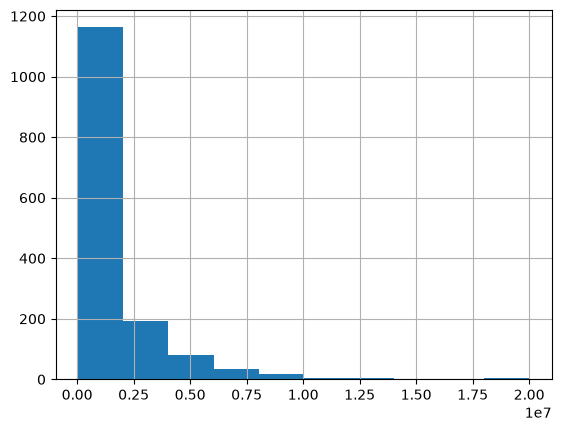

In [46]:
y_train.hist()

<Axes: >

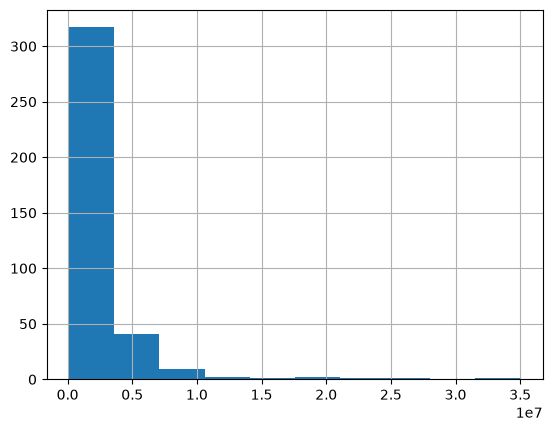

In [47]:
y_test.hist()

another clue is the actual prices, it's heavily skewed with a long right tail, which could be causing some estimates to be way off and extremely punishing in the rmse calculation since we have $(prediction - actual)^2$ in the RMSE formula, which blows up disproportionately for outliers

## 7. Log transforming the target

based on this, it looks like our linear regression model isn't performing well due to some issues with the data, so we should do some more feature engineering.

the first thing we can do is fix the heavy right tail (this would also mess up our data if we had decided to scale it so it's a good idea to get rid of it)

<Axes: >

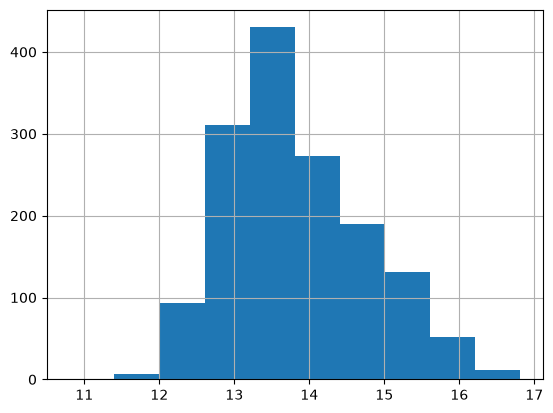

In [48]:
np.log(y_train).hist()

this looks way better, much more of a symmetrical, bell shaped (gaussian) distribution. let's replace our train/test prices with their logs

In [49]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

now let's retry the linear model to see if log transforming the prices helped to bring down the RMSE

In [50]:
lin_reg.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ 0.12,-0. , 0.01,...,-0.08, 0.01,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](36,)","['Year','Kilometer','Owner',...,'Drivetrain_RWD','Seller Type_Corporate', 'Seller Type_Individual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-233.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [51]:
y_pred = lin_reg.predict(X_test)

In [52]:
print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear model
print("R2: ", r2_score(y_test_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_test_log), np.exp(y_pred)))
print("RMSE: ", rmse)

Coef:  [ 1.21157609e-01 -3.65750881e-07  1.19915694e-02  3.67037015e-05
  3.55705527e-03  1.03631346e-03  3.79915202e-04  5.31438026e-04
 -1.63967755e-05 -4.24434424e-02  2.11873591e-03  2.33967676e-01
 -9.70228197e-02 -1.04815541e-01 -6.46445777e-02  1.46267884e-01
 -3.27814466e-02  5.83942114e-02  4.94913529e-01 -6.53578802e-02
 -8.11743591e-02 -4.15096621e-02  2.67509354e-01 -1.17809156e-01
  2.05399598e-01 -2.22170635e-01 -7.49144117e-02 -2.91357549e-01
  1.50975482e-01 -2.71348788e-02  3.07989117e-01 -1.87729258e-01
 -1.12805260e-01 -8.46431623e-02  1.32109218e-02 -1.77101870e-03]
Intercept:  -233.51703353457316
R2:  0.9163811247657795
RMSE:  1381138.7037515296


this looks MUCH better, our R2 score is solid.

our RMSE could do with some improvement, at 1,381,138 it's not the greatest, but significantly lower than what it was before.

let's see if theres any other features we can transform to make them nicer

## 8. Skewed features and outliers

the target looks better now, so let's check the features for the same problem.

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>,
        <Axes: title={'center': 'Owner'}>],
       [<Axes: title={'center': 'Engine'}>,
        <Axes: title={'center': 'Max Power'}>,
        <Axes: title={'center': 'Max Torque'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Seating Capacity'}>,
        <Axes: title={'center': 'Fuel Tank Capacity'}>, <Axes: >]],
      dtype=object)

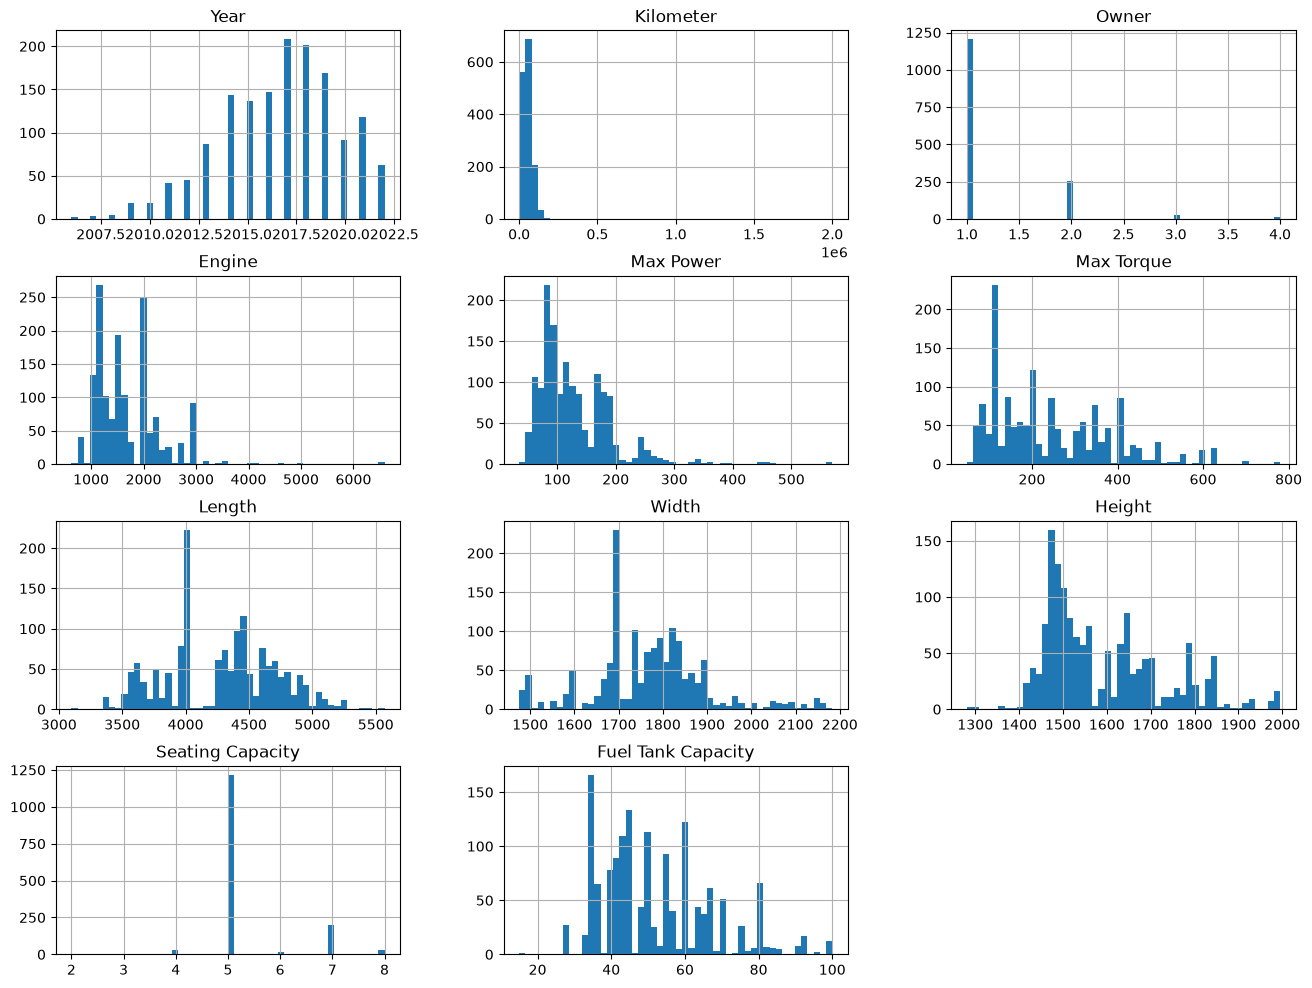

In [53]:
X_train.hist(bins=50, figsize=(16,12))

ouch, looks like a bunch of these are a bit skewed. the offenders are
- kilometer
- engine
- max power
- max torque

In [54]:
X_train["Kilometer"].max()

np.int64(2000000)

yeah that max value of 2 million is an outlier, looks like we can drop this, seems like an issue with the data entry

In [55]:
X_train.drop(X_train["Kilometer"].idxmax(), inplace=True)

In [56]:
X_train.describe()

,Year,Kilometer,Owner,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000
mean,2016.697597,52595.390521,1.234312,1685.675567,128.409012,244.238334,4279.662216,1767.405207,1591.561415,5.303071,52.184179
std,3.067490,39282.347354,0.525093,635.765218,62.522624,138.335670,435.513614,129.477618,134.096713,0.814205,15.008512
min,2006.000000,0.000000,1.000000,624.000000,35.000000,48.000000,3099.000000,1475.000000,1281.000000,2.000000,15.000000
25%,2015.000000,28588.000000,1.000000,1198.000000,83.000000,115.000000,3985.000000,1695.000000,1485.000000,5.000000,42.000000
50%,2017.000000,48972.500000,1.000000,1497.000000,116.000000,200.000000,4355.000000,1770.000000,1550.000000,5.000000,50.000000
75%,2019.000000,71667.250000,1.000000,1995.000000,169.000000,344.500000,4600.000000,1831.000000,1671.750000,5.000000,60.000000
max,2022.000000,925000.000000,4.000000,6592.000000,570.000000,780.000000,5569.000000,2183.000000,1995.000000,8.000000,100.000000


still have an offending outlier, this one has 1 million km. let's drop this too

In [57]:
X_train.drop(X_train["Kilometer"].idxmax(), inplace=True)

In [58]:
# what is our new max? 

X_train.loc[X_train["Kilometer"].idxmax()]

Year                        2018
Kilometer                 440000
Owner                          1
Engine                      1582
Max Power                  126.0
Max Torque                 260.0
Length                    4270.0
Width                     1780.0
Height                    1665.0
Seating Capacity             5.0
Fuel Tank Capacity          55.0
Make_BMW                   False
Make_Ford                  False
Make_Honda                 False
Make_Hyundai                True
Make_Jaguar                False
Make_Jeep                  False
Make_Kia                   False
Make_Land Rover            False
Make_MG                    False
Make_Mahindra              False
Make_Maruti Suzuki         False
Make_Mercedes-Benz         False
Make_Nissan                False
Make_Other                 False
Make_Renault               False
Make_Skoda                 False
Make_Tata                  False
Make_Toyota                False
Make_Volkswagen            False
Make_Volvo

this one is a little suspicious, let's drop it

In [59]:
X_train.drop(X_train["Kilometer"].idxmax(), inplace=True)

In [60]:
X_train["Kilometer"].max()

np.int64(240000)

ok lets just leave this now, 240k is not horrible

now let's try and fix up the outliers in engine

<Axes: >

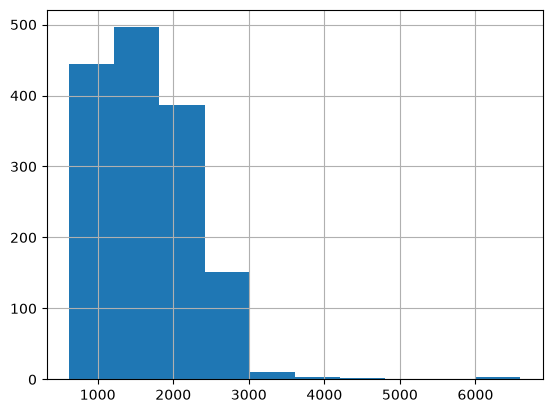

In [61]:
X_train["Engine"].hist()

In [62]:
X_train.loc[X_train["Engine"].idxmax()]

Year                        2011
Kilometer                  60000
Owner                          2
Engine                      6592
Max Power                  570.0
Max Torque                 780.0
Length                    5399.0
Width                     1948.0
Height                    1550.0
Seating Capacity             5.0
Fuel Tank Capacity          82.5
Make_BMW                   False
Make_Ford                  False
Make_Honda                 False
Make_Hyundai               False
Make_Jaguar                False
Make_Jeep                  False
Make_Kia                   False
Make_Land Rover            False
Make_MG                    False
Make_Mahindra              False
Make_Maruti Suzuki         False
Make_Mercedes-Benz         False
Make_Nissan                False
Make_Other                  True
Make_Renault               False
Make_Skoda                 False
Make_Tata                  False
Make_Toyota                False
Make_Volkswagen            False
Make_Volvo

this looks like it's just a high performance car, not an issue with the data so we can leave it. power and torque are related to engine size, so I would assume that those graphs are fine as well, with rare, high performance cars being the ones in the right tail.

now let's reindex the train targets to match up with our modified features

In [63]:
y_train = y_train.loc[X_train.index]
y_train_log = y_train_log.loc[X_train.index]

retry our model

In [64]:
lin_reg.fit(X_train, y_train_log)

y_pred = lin_reg.predict(X_test)

print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear model
print("R2: ", r2_score(y_test_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_test_log), np.exp(y_pred)))
print("RMSE: ", rmse)

Coef:  [ 1.16322716e-01 -1.52159238e-06  2.69449812e-03  7.69988080e-05
  3.13310971e-03  8.23487679e-04  4.21746464e-04  5.65763035e-04
  4.98252729e-04 -6.35031552e-02  2.99564028e-05  1.75861000e-03
 -4.81285692e-01 -4.77593157e-01 -4.26161514e-01 -7.66496894e-02
 -4.09809057e-01 -3.96491760e-01  2.62449784e-01 -5.77658448e-01
 -5.08927725e-01 -4.23017845e-01  5.10336252e-02 -6.20766537e-01
 -9.51173565e-02 -6.58236770e-01 -3.83842868e-01 -7.08963583e-01
 -2.10742681e-01 -3.45188730e-01 -2.34051405e-03 -1.39655384e-01
 -1.75268217e-02 -2.29945342e-03  2.28992627e-01  1.66057350e-01]
Intercept:  -224.44123902613555
R2:  0.9230032085259294
RMSE:  1388149.851019435


looks like our RMSE actually got worse, unfortunate, but the R2 got slightly better. however it was a pretty insignificant change to both.

let's just do a final log transform to the features with heavy right tails (engine/power/torque) and test it out, before moving on to another model.

In [65]:
X_train["Engine"] = np.log(X_train["Engine"])
X_train["Max Power"] = np.log(X_train["Max Power"])
X_train["Max Torque"] = np.log(X_train["Max Torque"])

In [66]:
X_test["Engine"] = np.log(X_test["Engine"])
X_test["Max Power"] = np.log(X_test["Max Power"])
X_test["Max Torque"] = np.log(X_test["Max Torque"])

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>,
        <Axes: title={'center': 'Owner'}>],
       [<Axes: title={'center': 'Engine'}>,
        <Axes: title={'center': 'Max Power'}>,
        <Axes: title={'center': 'Max Torque'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Seating Capacity'}>,
        <Axes: title={'center': 'Fuel Tank Capacity'}>, <Axes: >]],
      dtype=object)

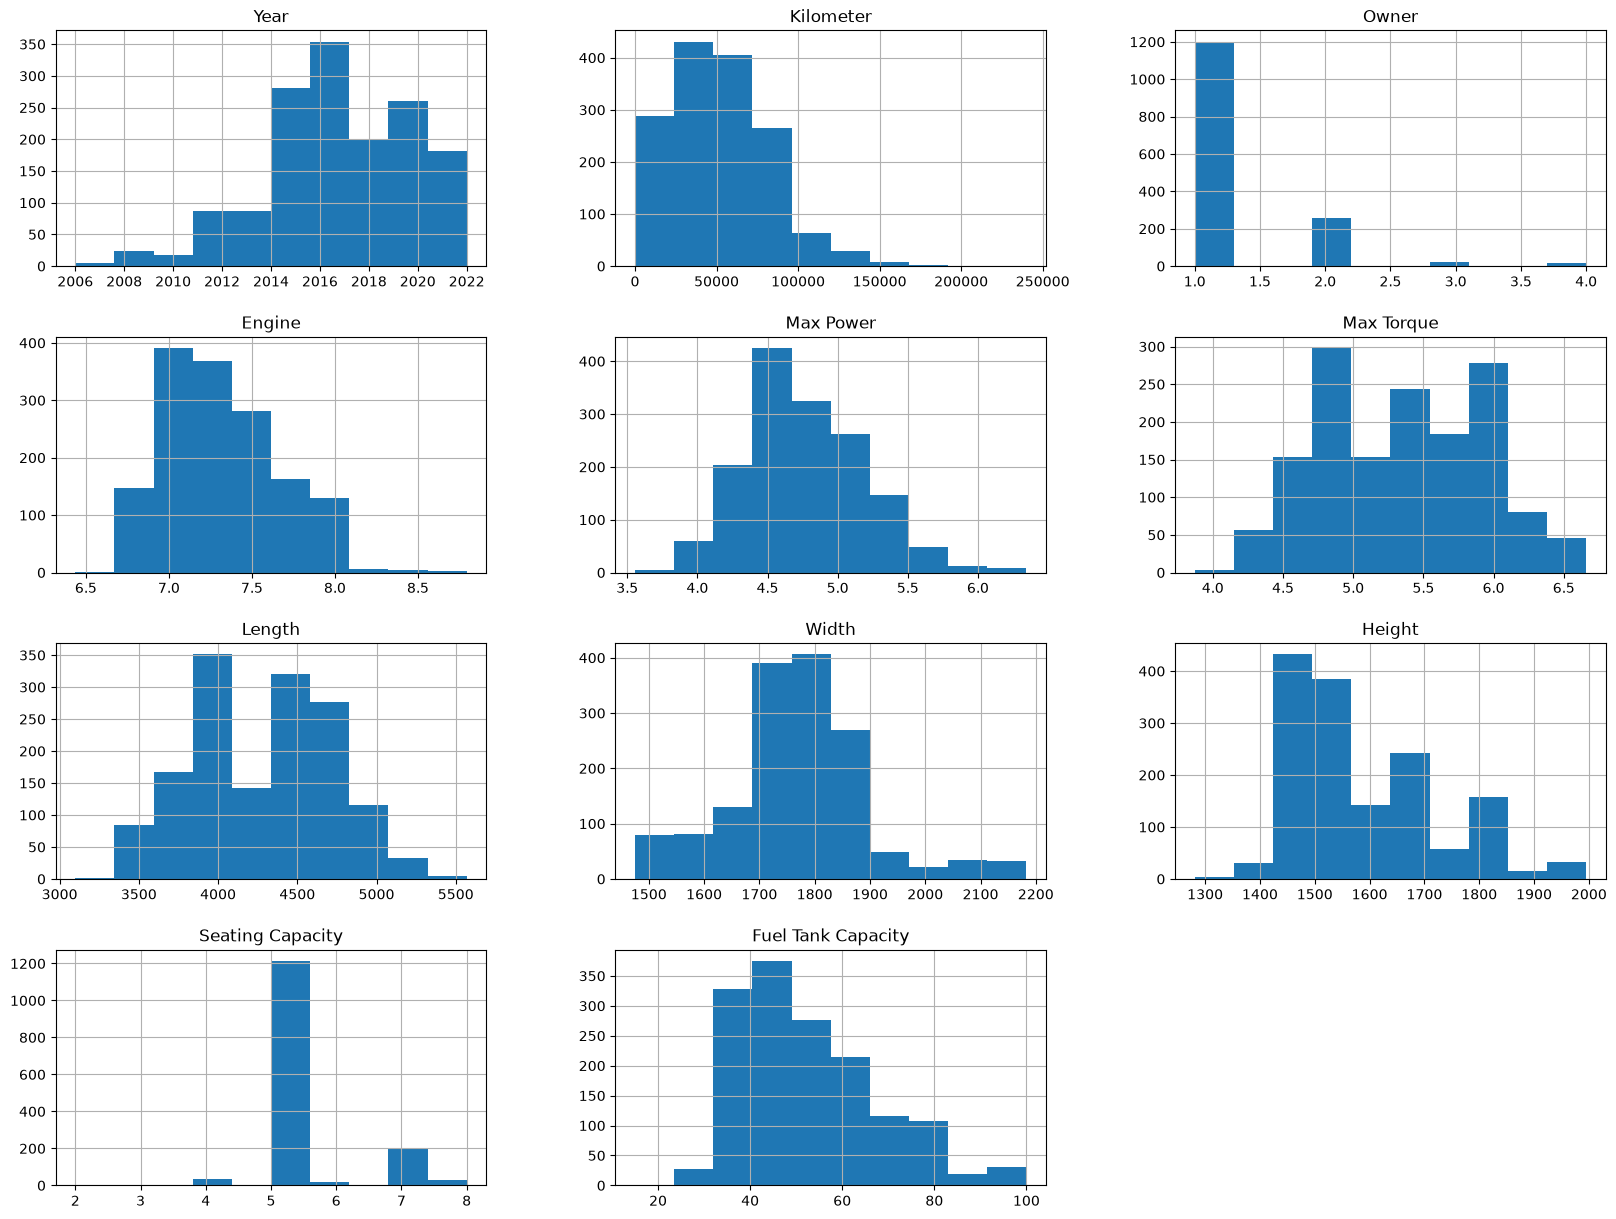

In [67]:
X_train.hist(figsize=(20, 15))

In [68]:
lin_reg.fit(X_train, y_train_log)

y_pred = lin_reg.predict(X_test)

print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear model
print("R2: ", r2_score(y_test_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_test_log), np.exp(y_pred)))
print("RMSE: ", rmse)

Coef:  [ 1.13583072e-01 -1.94267634e-06  2.70192052e-03  2.67768120e-01
  5.88442611e-01  1.86518345e-01  2.31040518e-04  2.40022350e-04
  3.03928604e-04 -4.59420974e-02  2.63213433e-03  3.07174826e-02
 -4.66047083e-01 -4.40093269e-01 -3.88643633e-01  1.87804558e-02
 -4.35807680e-01 -3.51347850e-01  3.19751846e-01 -5.16202337e-01
 -5.36957665e-01 -3.11942140e-01  8.81613080e-02 -5.05517953e-01
 -7.21113254e-03 -4.82634858e-01 -3.81739533e-01 -6.37006925e-01
 -2.19855128e-01 -3.12694607e-01 -5.47045131e-02 -1.20548517e-01
 -5.56373753e-02 -1.25516229e-02  2.33029980e-01  1.57085704e-01]
Intercept:  -222.47788651231997
R2:  0.9225317839850268
RMSE:  1880882.8241101825


## 9. Trying some other models

yeah not much change, looks like we need a more powerful model.

let's try a DecisionTreeRegressor, testing it first on the training data

In [69]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train_log)

y_pred = tree_reg.predict(X_train)

print("R2: ", r2_score(y_train_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred)))
print("RMSE: ", rmse)

R2:  0.9998368223515818
RMSE:  31698.13339016202


it looks like the model overfit on the training set, with an almost perfect R2 score.

we can confirm this by using scikit-learn's cross validation feature, splitting the training set into k folds, training on k-1 folds k times and evaluating on k different validation folds.

this gives us a better evaluation on how the model actually performs on unknown data

In [70]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(tree_reg, X_train, y_train_log, cv=10)
tree_rmse_cv = root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred_cv))

In [71]:
print(tree_rmse_cv)
print(r2_score(y_train_log, y_pred_cv))

1006882.9323496098
0.9008407475920935


looks like this probably isn't the greatest approach, with an RMSE of almost a million and an R2 score of 0.9 confirming that it was overfitting before.

let's move on to an even better model, a `RandomForestRegressor`, and eval via cv

> todo: come back and predict on the test data for these too, right now everything here is cv on the training set

In [72]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)

y_pred_cv = cross_val_predict(forest_reg, X_train, y_train_log, cv=10)
forest_rmse_cv = root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred_cv))

print(forest_rmse_cv)
print(r2_score(y_train_log, y_pred_cv))

782801.494018483
0.9478457026781396


okay this is a significant improvement, our RMSE and R2 score both have meaningful changes. let's train and measure RMSE on the training set

In [73]:
forest_reg.fit(X_train, y_train_log)
y_pred = forest_reg.predict(X_train)

print("R2: ", r2_score(y_train_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred)))
print("RMSE: ", rmse)

R2:  0.9931471777795188
RMSE:  339376.5562559507


okay it looks like there is still some overfitting going on, the RMSE is significantly lower here. but it's better than the Decision Tree.

however, a RandomForestRegressor looks to be our most promising option at this point. let's try 1 final model, Gradient Boosting, before we move on to fine tuning the model

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)

y_pred_cv = cross_val_predict(gb_reg, X_train, y_train_log, cv=10)
gb_rmse_cv = root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred_cv))

print(gb_rmse_cv)
print(r2_score(y_train_log, y_pred_cv))

gb_reg.fit(X_train, y_train_log)
y_pred = gb_reg.predict(X_train)

print("R2: ", r2_score(y_train_log, y_pred))
# transform the RMSE back to the actual price units
rmse = (root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred)))
print("RMSE: ", rmse)

644277.4381836028
0.951792971016294
R2:  0.9731225530048545
RMSE:  389708.75611690094


## 10. Fine tuning

this looks like it has further improvements, with lower overfitting. let's move ahead with this model for fine tuning.

instead of using GridSearchCV which is exhaustive but would be too time consuming, we can try RandomizedSearch. we also don't know what hyperparameters matter, so it's not worth it to waste compute thoroughly testing something that may not be very impactful.

typically, the most impactful hyperparameters for a GradientBoostingRegressor are
- n_estimators
    - the number of trees, too many can cause the overfitting we have been seeing, too low could be underfitting
- learning_rate
    - controls how much each tree corrects the previous errors, again correlated with under/over fitting
- max_depth
    - how complex each individual tree is, more complex means a stronger fit

adjusting these parameters can help us fix our overfitting problem.

so let's give each parameter a distribution of possible values to choose from, and see what the best combination of params the search gives us

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform

# give each parameter a distribution of possible values to randomly choose from
param_distributions = {
    "n_estimators": randint(100, 1000),
    "learning_rate": uniform(0.01, 0.3),
    "max_depth": randint(2, 6)
}

rnd_search = RandomizedSearchCV(gb_reg, param_distributions=param_distributions,
                                n_iter=20, cv=5, scoring="neg_root_mean_squared_error", random_state=42)

rnd_search.fit(X_train, y_train_log)
print(rnd_search.best_params_)

{'learning_rate': np.float64(0.1012726728878613), 'max_depth': 3, 'n_estimators': 352}


our scores, but this is still in log form unfortunately

In [76]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.367281,0.004930,0.001597,0.000029,0.101273,3,352,"{'learning_rate': 0.1012726728878613, 'max_dep...",-0.178939,-0.187838,-0.202367,-0.165223,-0.205536,-0.187981,0.014932,1
0,0.270872,0.005021,0.001437,0.000080,0.122362,2,370,"{'learning_rate': 0.12236203565420874, 'max_de...",-0.173685,-0.198258,-0.200501,-0.165852,-0.204520,-0.188563,0.015673,2
9,0.427219,0.009610,0.001867,0.000380,0.139584,2,574,"{'learning_rate': 0.13958350559263474, 'max_de...",-0.175205,-0.192950,-0.208984,-0.165730,-0.203879,-0.189350,0.016538,3
14,0.699398,0.014112,0.002191,0.000110,0.150029,2,918,"{'learning_rate': 0.150028867974394, 'max_dept...",-0.172595,-0.201920,-0.202278,-0.169035,-0.206089,-0.190383,0.016084,4
12,0.686770,0.015848,0.002239,0.000028,0.037182,3,662,"{'learning_rate': 0.03718193035984624, 'max_de...",-0.178578,-0.188348,-0.211410,-0.170998,-0.205782,-0.191024,0.015469,5


let's get the best model from our search, and test it out

In [77]:
final_model = rnd_search.best_estimator_

y_pred = final_model.predict(X_train)

y_pred_cv = cross_val_predict(final_model, X_train, y_train_log, cv=10)
final_model_rmse_cv = root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred_cv))

print(final_model_rmse_cv)
print(r2_score(y_train_log, y_pred_cv))

print(r2_score(y_train_log, y_pred))
print(root_mean_squared_error(np.exp(y_train_log), np.exp(y_pred)))

574673.0793455412
0.9582342483548388
0.986632274176167
217739.0622855634


looks like our overfitting issue is better now, the fine tuning helped. running a broader search doesn't seem like it would help, since looking at the best params we got they were all in the middle of the range, nothing was at a boundary, meaning that there probably isn't anything significantly better outside of our range.

it looks like this is it, now all that's left to do is to evaluate our model on the test set.

## 11. Evaluating on the test set

In [78]:
y_pred = final_model.predict(X_test)
print(r2_score(y_test_log, y_pred))
print(root_mean_squared_error(np.exp(y_test_log), np.exp(y_pred)))

0.9567248618569184
1909562.2640136397


an R2 score of 0.96 and a RMSE of 2 million is not good, might be an issue with a huge outlier vehicle. let's check

In [79]:
residuals = np.exp(y_test_log) - np.exp(y_pred)
worst_idx = residuals.abs().idxmax()
print(residuals.loc[worst_idx], y_test.loc[worst_idx])

23492934.67060585 35000000


this confirms it, we underestimated hugely on that one 35 million car, by about 23.5 million, since the model had never seen anything that expensive during training, which is a fundamental limitation of this approach. this single error accounts for about 40% of the entire RMSE, with other expensive outliers no doubt contributing to the RMSE.

> next steps: figure out some way to deal with outliers, or a model family that can extrapolate (perhaps an ensemble with a linear regression model?)

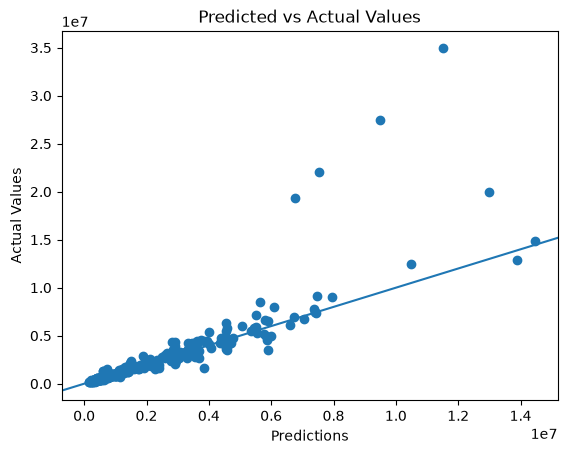

In [80]:
plt.scatter(np.exp(y_pred), np.exp(y_test_log))
plt.title("Predicted vs Actual Values")
plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.axline((0,0), slope=1)
plt.show()

we can see that the model works quite well for the vast majority of entries, however a handful of outliers are way off, due to the fact that the training set had not seen such large values

In [81]:
y_train.nlargest(10)

1246    20000000
1369    20000000
1912    18500000
442     18500000
977     18000000
95      16200000
1576    13100000
542     13000000
1742    12500000
160     11500000
Name: Price, dtype: int64

In [82]:
y_test.nlargest(10)

483     35000000
1305    27500000
582     22000000
1890    20000000
1313    19300000
1803    14900000
1370    12900000
259     12500000
1388     9100000
464      9000000
Name: Price, dtype: int64

## 12. Feature importance

let's see which features the model actually leaned on.

In [83]:
importances = final_model.feature_importances_

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
    }).sort_values(by='Importance', ascending=False)

In [84]:
print(feature_importances)

                   Feature  Importance
4                Max Power    0.629045
0                     Year    0.121978
7                    Width    0.079958
5               Max Torque    0.054029
31     Transmission_Manual    0.036562
1                Kilometer    0.026478
6                   Length    0.013854
3                   Engine    0.009577
8                   Height    0.006395
22      Make_Mercedes-Benz    0.005193
10      Fuel Tank Capacity    0.004661
24              Make_Other    0.002166
32          Drivetrain_FWD    0.002108
27               Make_Tata    0.001617
14            Make_Hyundai    0.001430
9         Seating Capacity    0.000920
18         Make_Land Rover    0.000770
28             Make_Toyota    0.000639
12               Make_Ford    0.000439
2                    Owner    0.000417
19                 Make_MG    0.000383
16               Make_Jeep    0.000328
20           Make_Mahindra    0.000228
13              Make_Honda    0.000133
25            Make_Renaul

this shows us the driving factors towards a higher price. Max Power being the highest makes sense, more expensive cars/brands typically have more powerful engines. Year following behind also makes sense, newer cars command a premium. interestingly, I thought that make would be impactful on the price, however I suppose there were just too many options for the model to learn on it properly. however Max Power substituted here, with luxury cars typically having larger engines. Width again ties in to the luxury car aspect, with larger, more premium cars tending to be larger and more spacious, and Max Torque relating to engine. the rest of the features seem to be nearly inconsequential.

overall, the model seemed to take into account different features when making a decision, however the intuition behind them was the same: larger, more premium, and more powerful vehicles tend to command the highest price.

## 13. Comparing every model we tried

last thing, a summary table of all the models. everything here uses the same metric (10 fold cv on the training set, with the RMSE converted back out of log space into real prices) so the comparison is fair. linear regression never got cross validated earlier, it was only evaluated on the single train/test split, so it gets done properly here too.

In [85]:
models = {
    "Linear Regression": lin_reg,
    "Decision Tree": tree_reg,
    "Random Forest": forest_reg,
    "Gradient Boosting (default)": gb_reg,
    "Gradient Boosting (tuned)": final_model,
}

results = []
for name, model in models.items():
    preds_log = cross_val_predict(model, X_train, y_train_log, cv=10)
    rmse = root_mean_squared_error(np.exp(y_train_log), np.exp(preds_log))
    r2 = r2_score(y_train_log, preds_log)
    results.append({"Model": name, "CV RMSE": rmse, "CV R2": r2})

comparison_df = pd.DataFrame(results).sort_values("CV RMSE").reset_index(drop=True)
comparison_df

,Model,CV RMSE,CV R2
0,Gradient Boosting (tuned),5.746731e+05,0.958234
1,Gradient Boosting (default),6.442774e+05,0.951793
2,Random Forest,7.828015e+05,0.947846
3,Linear Regression,9.007246e+05,0.938103
4,Decision Tree,1.006883e+06,0.900841


## Wrap up

the tuned GradientBoostingRegressor was the best of the lot at ~575k cv RMSE and 0.958 cv R2, and it holds up on the test set with an R2 of 0.96. the headline test RMSE of ~1.9M is misleading though, it's almost entirely driven by a few multi-million rupee cars that the model has no way of predicting because nothing that expensive existed in the training data.

so realistically this does a decent job on normal cars and falls apart on supercars. see the next steps note above for what I'd try about that.